In [1]:
import os
import random
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import cv2
from tensorflow import keras
import tensorflow as tf
import keras.backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout, Activation
from tensorflow.keras.layers import BatchNormalization, Reshape, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

*Print list of input*

In [2]:
print(os.listdir("../input/bloodcelltype"))

['monocyte', 'neutrophil', 'basophil', 'lymphocyte', 'platelet']


*Splitting of datasets into train and test*

In [3]:
import os
import shutil
from sklearn.model_selection import train_test_split

dataset_path = "../input/bloodcelltype"
output_train_path = "/kaggle/working/train"
output_test_path = "/kaggle/working/test"

# Create train and test directories
os.makedirs(output_train_path, exist_ok=True)
os.makedirs(output_test_path, exist_ok=True)

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        image_files = os.listdir(class_path)
        # Adjust the split to 80% training, 20% testing
        train_files, test_files = train_test_split(image_files, test_size=0.2, random_state=42)

        # Create class directories in both train and test folders
        os.makedirs(os.path.join(output_train_path, class_name), exist_ok=True)
        os.makedirs(os.path.join(output_test_path, class_name), exist_ok=True)

        # Copy train files
        for file_name in train_files:
            shutil.copy(os.path.join(class_path, file_name),
                        os.path.join(output_train_path, class_name, file_name))

        # Copy test files
        for file_name in test_files:
            shutil.copy(os.path.join(class_path, file_name),
                        os.path.join(output_test_path, class_name, file_name))

print("The dataset has been successfully split into train and test sets")


The dataset has been successfully split into train and test sets


In [4]:
# Verify the number of images in each class directory in the train and validation directories
for class_name in os.listdir(output_train_path):
    class_path = os.path.join(output_train_path, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"Class {class_name}: {num_images} images in train")

for class_name in os.listdir(output_test_path):
    class_path = os.path.join(output_test_path, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"Class {class_name}: {num_images} images in validation")


Class lymphocyte: 971 images in train
Class platelet: 1878 images in train
Class monocyte: 1136 images in train
Class basophil: 974 images in train
Class neutrophil: 2663 images in train
Class lymphocyte: 243 images in validation
Class platelet: 470 images in validation
Class monocyte: 284 images in validation
Class basophil: 244 images in validation
Class neutrophil: 666 images in validation


In [5]:
import os

# Correct the path
print(os.listdir("/kaggle/working/train"))
print(os.listdir("/kaggle/working/test"))

['lymphocyte', 'platelet', 'monocyte', 'basophil', 'neutrophil']
['lymphocyte', 'platelet', 'monocyte', 'basophil', 'neutrophil']


*Sample Images*

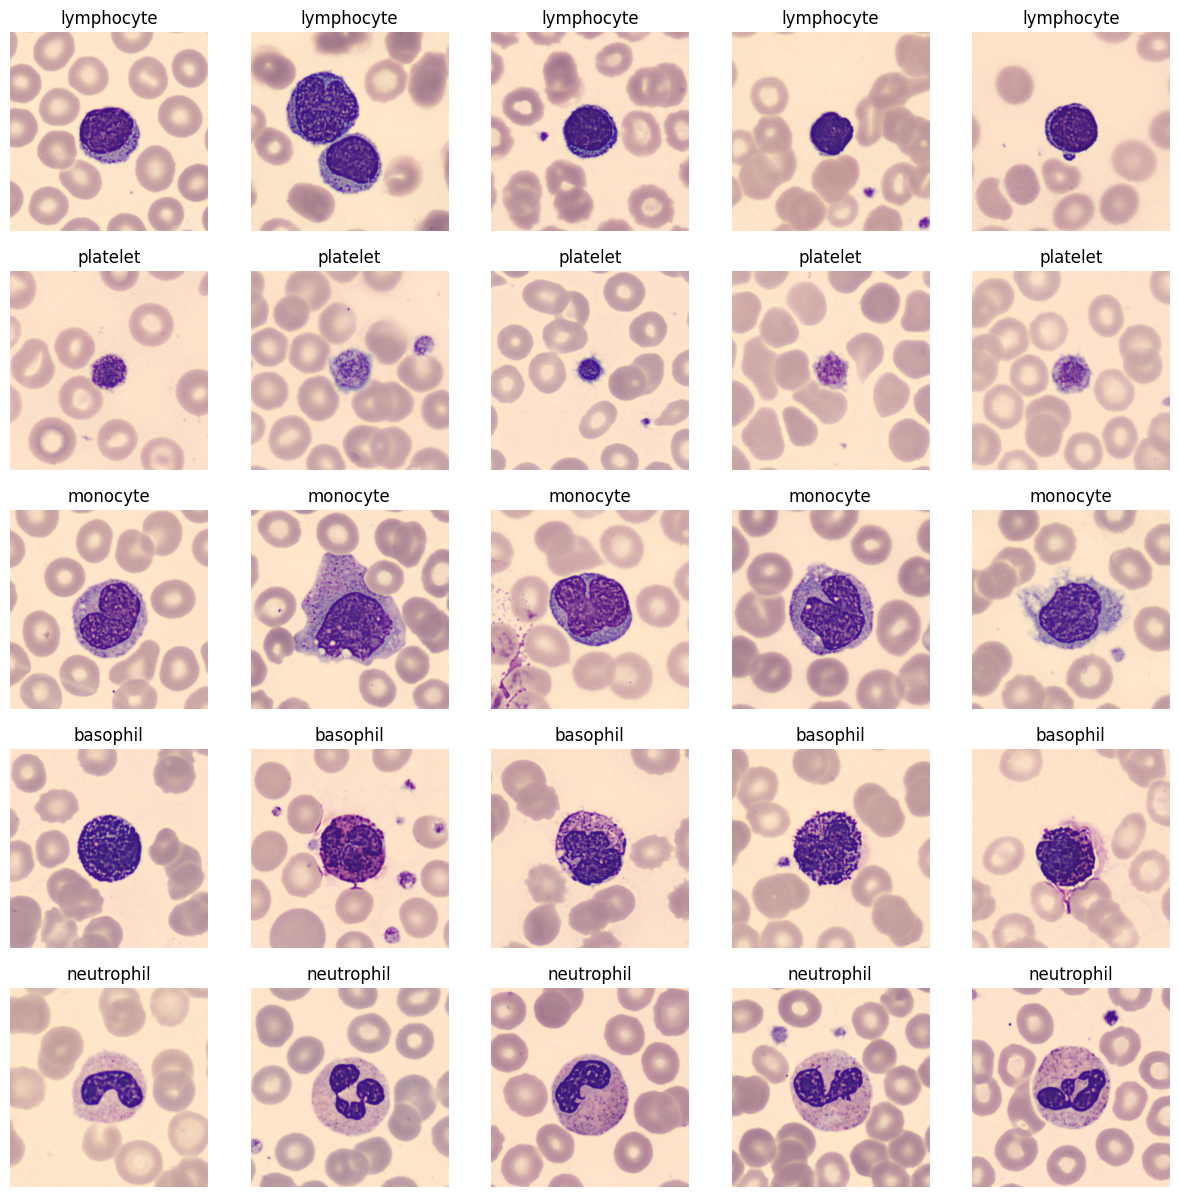

In [6]:
#Get the list of class names (subfolder names) in the train directory
class_names = os.listdir(output_train_path)

selected_images = []
for class_name in class_names:
    class_path = os.path.join(output_train_path, class_name)
    
    if os.path.isdir(class_path):
        image_files = os.listdir(class_path)
        rand_images = random.sample(image_files, min(5, len(image_files))) #Randomly select 5 animals from this class
        selected_images.extend([(os.path.join(class_path, im), class_name) for im in rand_images]) #Add selected images to the list

num_images = len(selected_images)
num_columns = 5
num_rows = (num_images // num_columns) + (1 if num_images % num_columns > 0 else 0)

fig = plt.figure(figsize=(num_columns * 3, num_rows * 3))

for i, (im_path, label) in enumerate(selected_images):
    im = cv2.imread(im_path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    plt.subplot(num_rows, num_columns, i + 1)
    plt.imshow(im)
    plt.title(label)
    plt.axis('off')

plt.show()


*Data split to train and validation*

In [7]:
import os
import pandas as pd

# Path to train directory
train_dir = '/kaggle/working/train'

categories = os.listdir(train_dir)

# Collect image paths and labels
image_paths = []
labels = []

for category in categories:
    category_path = os.path.join(train_dir, category)
    if os.path.isdir(category_path) :
        for image_name in os.listdir(category_path):
            if image_name.endswith('.jpg'):
                image_paths.append(os.path.join(category_path, image_name))
                labels.append(category)


image_paths = np.array(image_paths)
labels = np.array(labels)

validation_split = 0.2

idxs = np.random.permutation(range(len(labels))) 
train_idx = idxs[int(validation_split * len(labels)):]
val_idx = idxs[:int(validation_split * len(labels))]

# Split data into training and validation sets (80% train, 20% validation)
train_image_paths = image_paths[train_idx]
val_image_paths = image_paths[val_idx]
train_labels = labels[train_idx]
val_labels = labels[val_idx]

print(len(train_image_paths), len(val_image_paths))

6098 1524


*Data Augmentation*

In [8]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import os

# Define the data augmentation transformations for training
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255,
    horizontal_flip=True,
    rotation_range=15,
    shear_range=0.1,  
    width_shift_range=0.1,  # Wider width shift
    height_shift_range=0.1,  # Wider height shift
    vertical_flip=True,
    fill_mode='nearest'
)
val_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1/255)

batch_size = 64
target_size=(150, 150)

train_df = pd.DataFrame({
    'filename' : train_image_paths,
    'label' : train_labels
})

val_df = pd.DataFrame({
    'filename' : val_image_paths,
    'label' : val_labels
})

# Training generator
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory='/kaggle/working/train',
    x_col='filename',
    y_col='label',
    class_mode='categorical',
    batch_size=batch_size,
    target_size=target_size
)

# Validation generator
val_generator = val_datagen.flow_from_dataframe(
    val_df,
    directory='/kaggle/working/train',  # Path to the test directory
    x_col='filename',
    y_col='label',
    class_mode='categorical',
    batch_size=batch_size,
    target_size=target_size
)


Found 6098 validated image filenames belonging to 5 classes.
Found 1524 validated image filenames belonging to 5 classes.


In [9]:
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")


Training samples: 6098
Validation samples: 1524


In [10]:
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"Class {class_name}: {num_images} images")

Class monocyte: 1420 images
Class neutrophil: 3329 images
Class basophil: 1218 images
Class lymphocyte: 1214 images
Class platelet: 2348 images


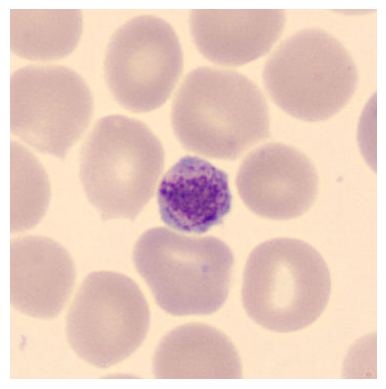

In [11]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to your train directory (in Kaggle environment)
train_dir = '/kaggle/working/train'

# Select a random class (category)
class_name = random.choice(os.listdir(train_dir))

# Select a random image from that class
class_path = os.path.join(train_dir, class_name)
image_file = random.choice(os.listdir(class_path))
image_path = os.path.join(class_path, image_file)

# Open and display the image
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()


*Modeling*

In [12]:
base_model = tf.keras.applications.InceptionV3(input_shape=(299,299,3),include_top=False,weights="imagenet")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
from tensorflow.keras.applications import InceptionV3

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

In [14]:
for layer in base_model.layers[:-10]:
    layer.trainable = False
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense

inputs = Input(shape=(150, 150, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
x = Dense(128, activation='relu')(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(5, activation='softmax')(x)
model = Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ inception_v3 (Functional)            │ (None, 3, 3, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,082,213 (84.24 MB)

 Trainable params: 279,621 (1.07 MB)

 Non-trainable params: 21,802,592 (83.17 MB)

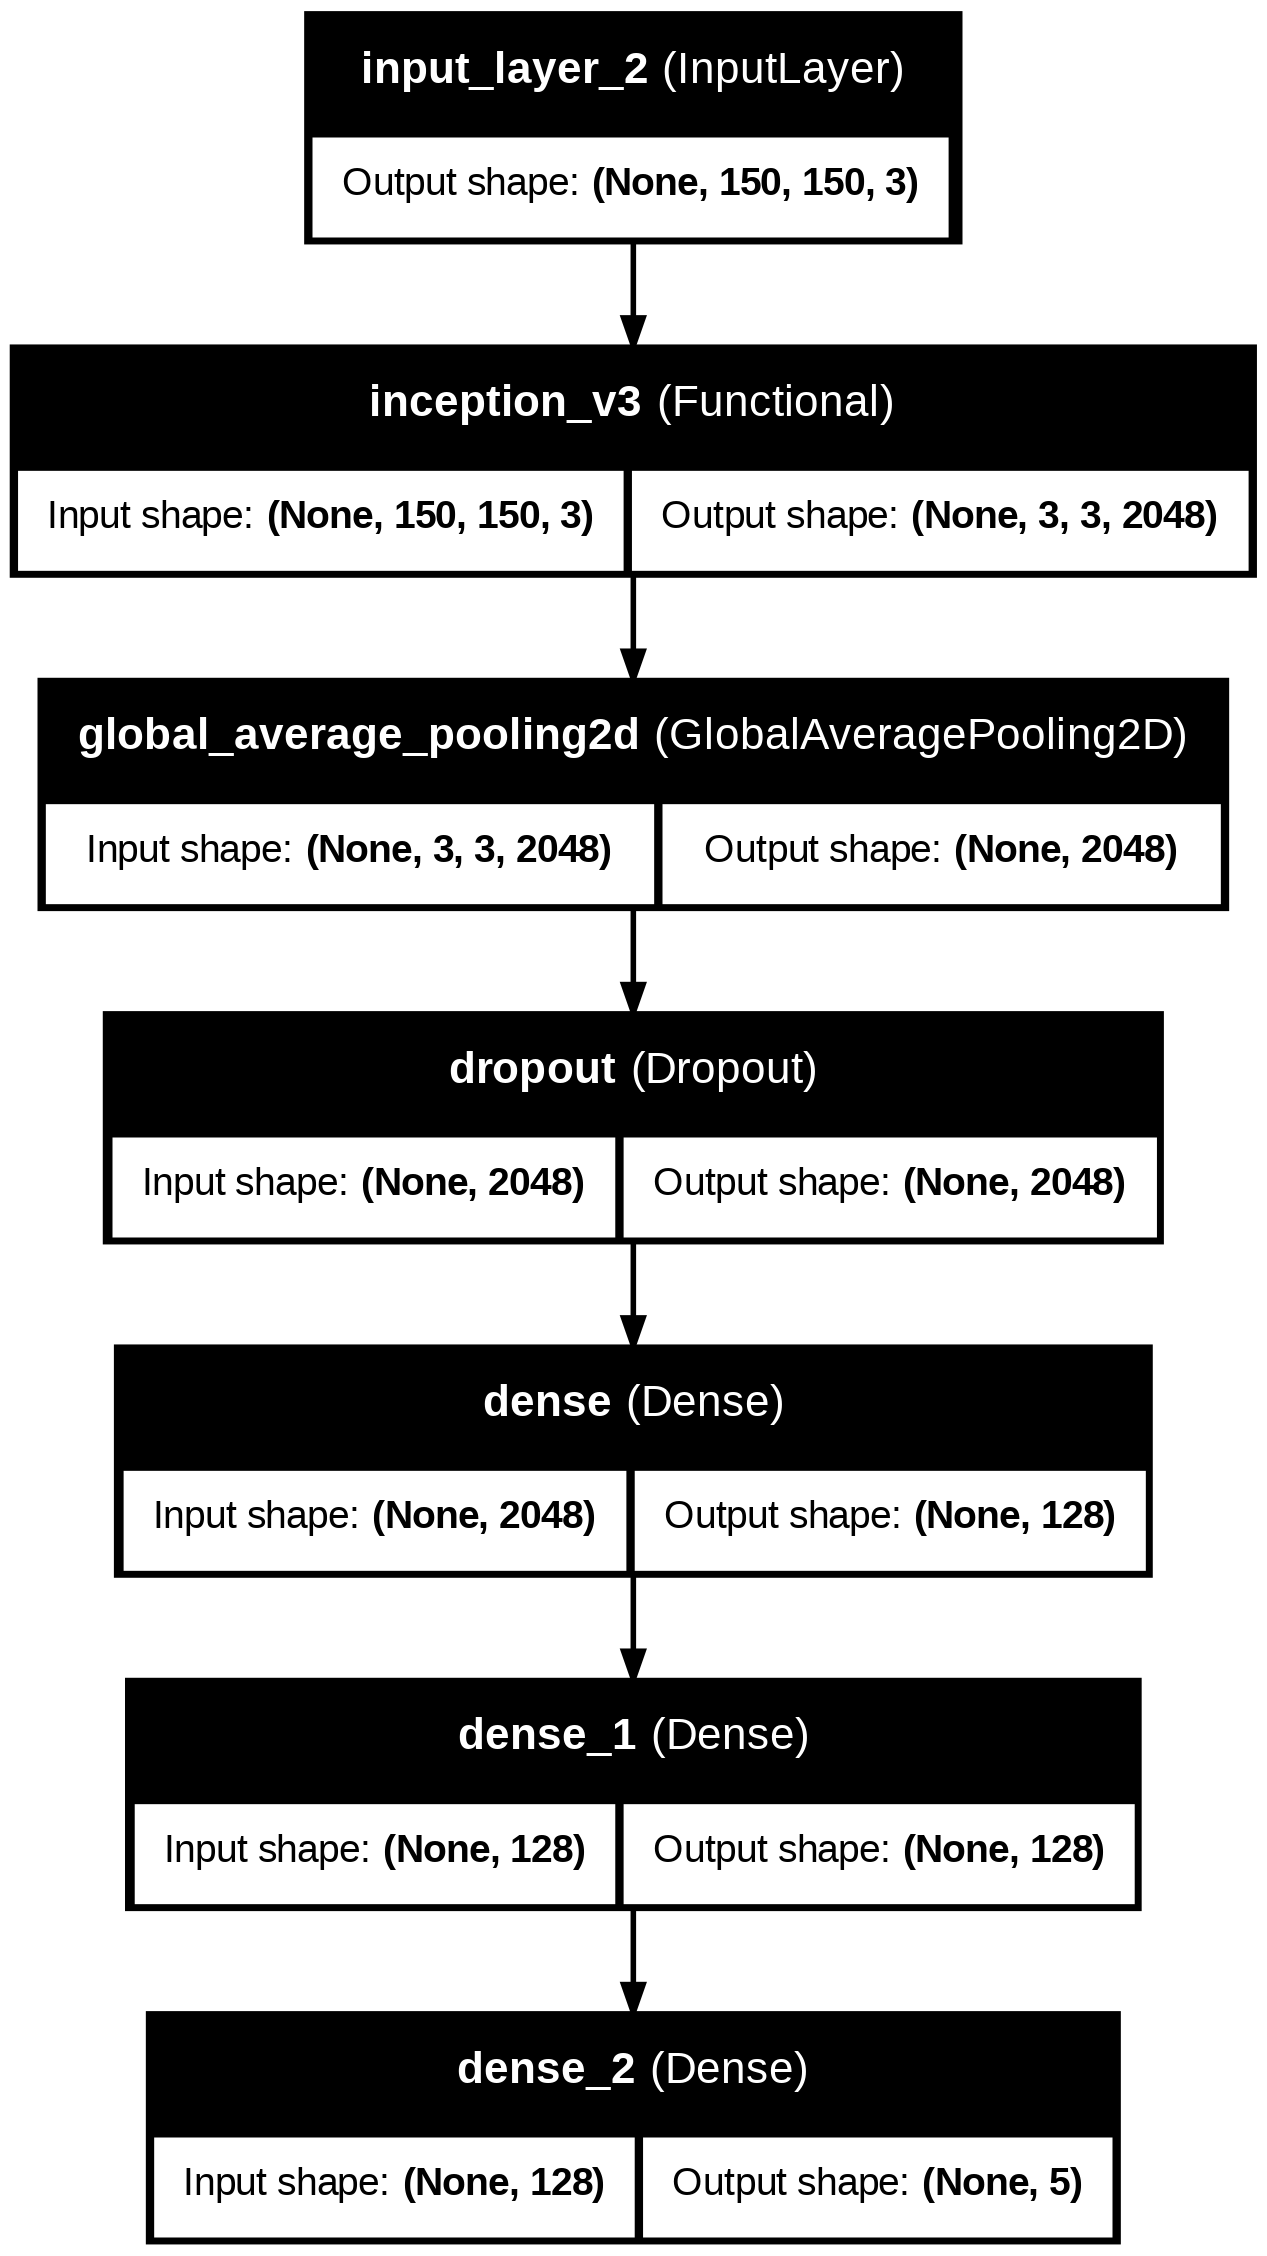

In [15]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image
plot_model(model, to_file='convnet.png', show_shapes=True,show_layer_names=True)
Image(filename='convnet.png')

In [16]:
def f1_score(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [17]:
METRICS = [
      tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall'),  
      tf.keras.metrics.AUC(name='auc'),
        f1_score,
]

In [18]:
lrd = ReduceLROnPlateau(monitor = 'val_loss',patience = 3,verbose = 1,factor = 0.50, min_lr = 1e-6)

mcp = ModelCheckpoint('model.keras')

es = EarlyStopping(verbose=1, patience=3)

In [19]:
model.compile(optimizer='Adam', loss = 'categorical_crossentropy',metrics=['accuracy'])

*Training*

In [20]:
#Define the test data generator
test_datagen = ImageDataGenerator(rescale=1.0 /255)

#Create the test generator
test_generator = test_datagen.flow_from_directory(
    directory="/kaggle/working/train",
    target_size=(150, 150), #Match the input size of the model
    batch_size=batch_size,
    class_mode='categorical' 
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    verbose=1,
    callbacks=[lrd, mcp, es]
)

#Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Accuracy: {test_accuracy * 100:.2f}%")

Found 7622 images belonging to 5 classes.
Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 569ms/step - accuracy: 0.7142 - loss: 0.7688 - val_accuracy: 0.9101 - val_loss: 0.2604 - learning_rate: 0.0010
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 385ms/step - accuracy: 0.9130 - loss: 0.2548 - val_accuracy: 0.9226 - val_loss: 0.2266 - learning_rate: 0.0010
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 392ms/step - accuracy: 0.9251 - loss: 0.2184 - val_accuracy: 0.9134 - val_loss: 0.2446 - learning_rate: 0.0010
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 389ms/step - accuracy: 0.9242 - loss: 0.2148 - val_accuracy: 0.9396 - val_loss: 0.1881 - learning_rate: 0.0010
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 390ms/step - accuracy: 0.9271 - loss: 0.2178 - val_accuracy: 0.9429 - val_loss: 0.1728 - learning_rate: 0.0010
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 389ms/step - accuracy: 0.9350 - loss: 0.1924 - val_accuracy: 0.9383 - val_loss: 0.1824 - learning_rate: 0.0010
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 40

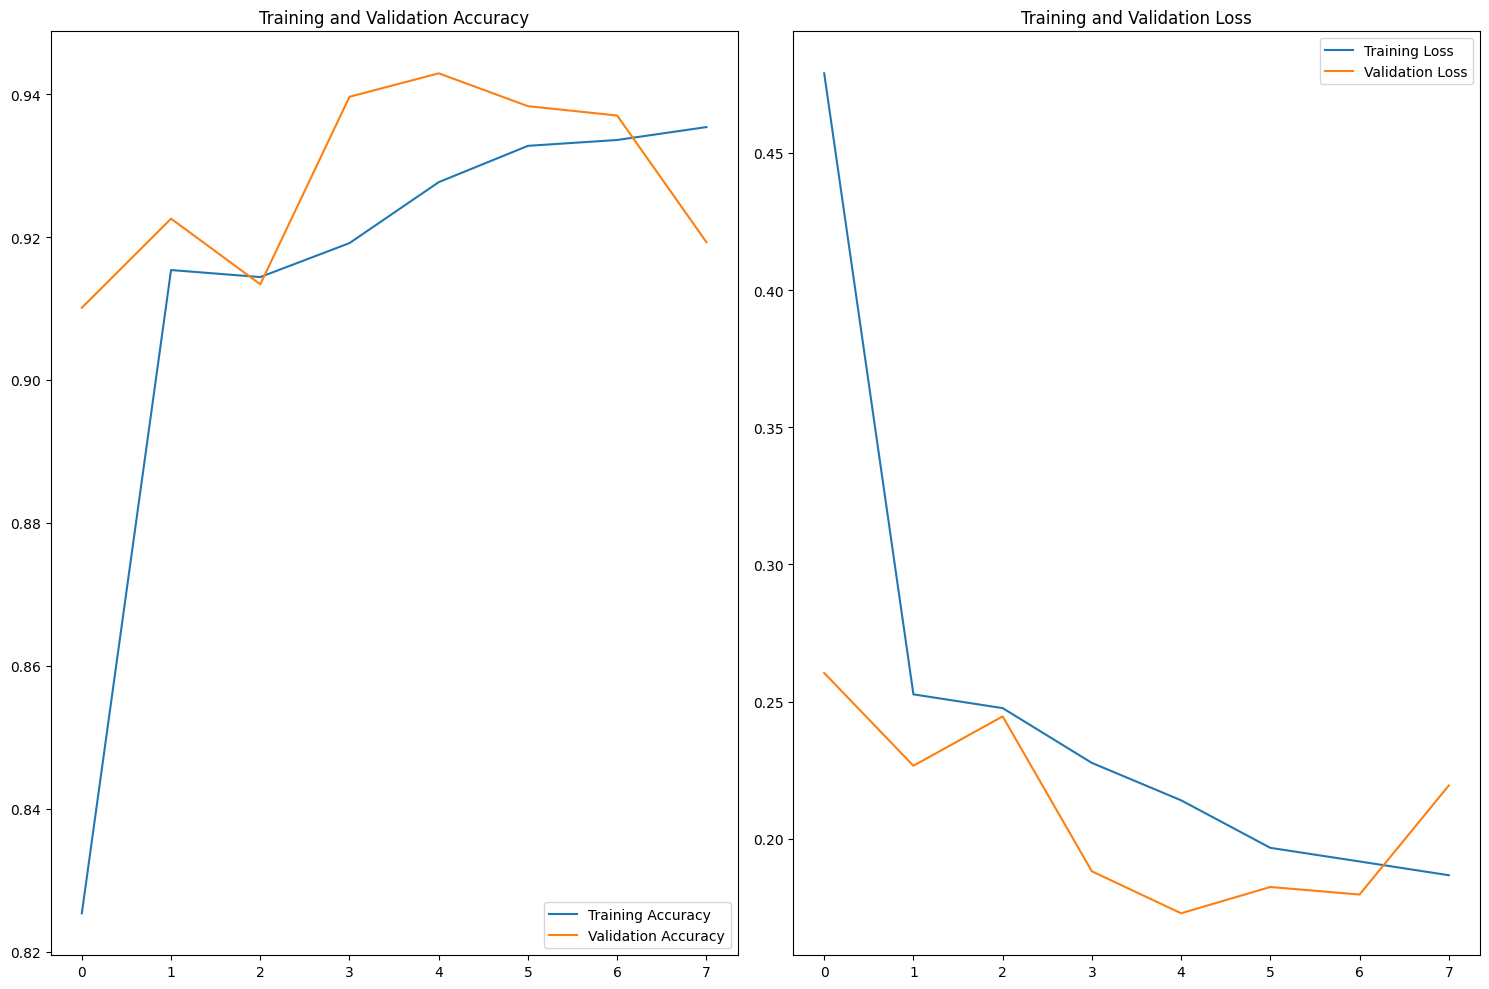

In [21]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(history.history['val_loss']))

plt.figure(figsize=(15, 10))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

# Adjust the layout to avoid overlap
plt.tight_layout()

plt.show()


In [22]:
#Define test ImageDataGenerator
test_datagen = keras.preprocessing.image.ImageDataGenerator(rescale = 1/255)

#Create the test generator
test_generator = test_datagen.flow_from_directory(
    directory='/kaggle/working/test',
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode=None,
    shuffle=False
)

#Print the number of validated image filenames
print(f"Found {len(test_generator.filenames)} validated image filenames.")

Found 1907 images belonging to 5 classes.
Found 1907 validated image filenames.


*Prediction*

In [23]:
#Predict on the test set
y_pred = (model.predict(test_generator) > 0.5).astype("int32")

#Convert predictions to a DataFrame
y_pred_df = pd.DataFrame(y_pred, columns=[f"class_(i)" for i in range (y_pred.shape[1])])

#Add filenames from the test generator to the DataFrame
y_pred_df['filename'] = test_generator.filenames

#Display the predictions DataFrame
y_pred_df

30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 385ms/step


,class_(i),class_(i),class_(i),class_(i),class_(i),filename
0,1,0,0,0,0,basophil/BA_111710.jpg
1,1,0,0,0,0,basophil/BA_115323.jpg
2,1,0,0,0,0,basophil/BA_119883.jpg
3,1,0,0,0,0,basophil/BA_120278.jpg
4,1,0,0,0,0,basophil/BA_120688.jpg
...,...,...,...,...,...,...
1902,0,0,0,0,1,platelet/PLATELET_989059.jpg
1903,0,0,0,0,1,platelet/PLATELET_989621.jpg
1904,0,0,0,0,1,platelet/PLATELET_99203.jpg
1905,0,0,0,0,1,platelet/PLATELET_993036.jpg


*Confusion Matrix*

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step


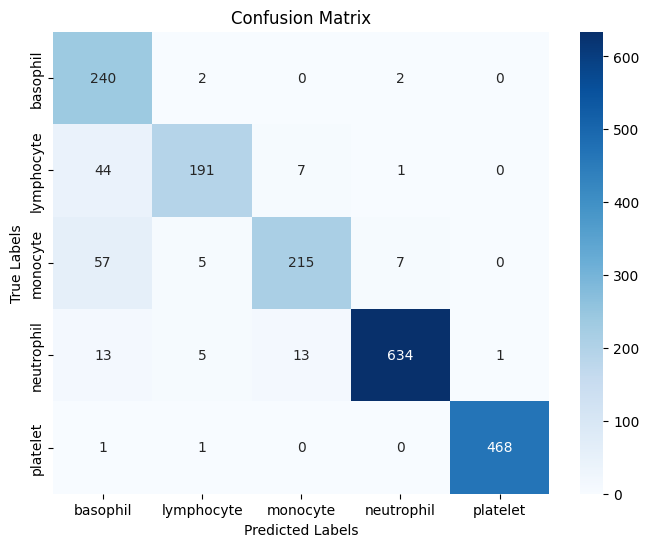

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# get true labels for the test set
true_labels = test_generator.classes 

# predict the classes for the test set
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)  # Convert probabilities to class labels

# generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)

# define class labels
class_labels = list(test_generator.class_indices.keys())


# plotting the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

        Class  Precision  Recall  F1-Score  Support
0    basophil       0.68    0.98      0.80      244
1  lymphocyte       0.94    0.79      0.85      243
2    monocyte       0.91    0.76      0.83      284
3  neutrophil       0.98    0.95      0.97      666
4    platelet       1.00    1.00      1.00      470


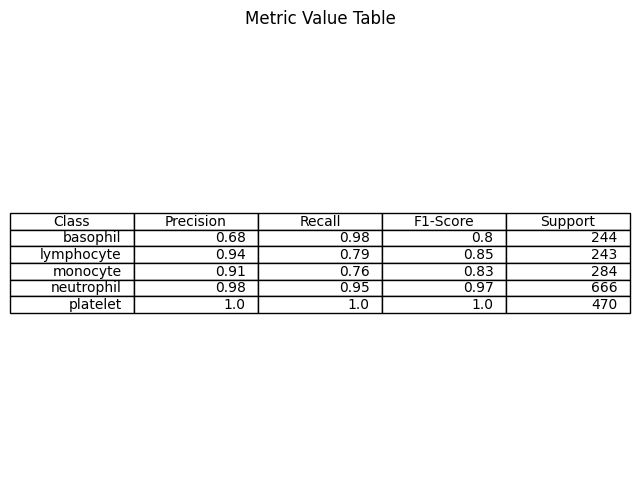

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use your confusion matrix (already calculated as 'cm')
# 'cm' should be defined from your previous code
TP = np.diag(cm)  # True Positives
FP = np.sum(cm, axis=0) - TP  # False Positives
FN = np.sum(cm, axis=1) - TP  # False Negatives
support = np.sum(cm, axis=1)  # Total actual occurrences

# Calculate Precision, Recall, F1-Score
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

# Create a DataFrame for the metrics
metrics_df = pd.DataFrame({
    'Class': class_labels,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_score,
    'Support': support
})

# Round values for readability
metrics_df = metrics_df.round(2)

# Display the table
print(metrics_df)

# Plot the table
fig, ax = plt.subplots(figsize=(8, 6))
ax.axis('tight')
ax.axis('off')
ax.table(cellText=metrics_df.values,
         colLabels=metrics_df.columns,
         loc='center')

plt.title("Metric Value Table")
plt.show()
